# Economic growth and Life expectancy in the world

### Viktoria Ivanova - 7MI3400799

After advanced research of the provided data about Economic growth, meaning the quantity or quality of the many goods and services that people produce and Life expectancy throughout the contries in the world, all features were taken into account in order to retrieve meaningful information about the contries and their population.

### Imports

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Loading the data

##### GDP per capita

In [19]:
gdp_df = pd.read_csv("gdp-per-capita-worldbank.csv")
gdp_df

,Entity,Code,Year,"GDP per capita, PPP (constant 2021 international $)",World regions according to OWID
0,Afghanistan,AFG,2000,1617.8264,NaN
1,Afghanistan,AFG,2001,1454.1108,NaN
2,Afghanistan,AFG,2002,1774.3087,NaN
3,Afghanistan,AFG,2003,1815.9282,NaN
4,Afghanistan,AFG,2004,1776.9182,NaN
...,...,...,...,...,...
7306,Zimbabwe,ZWE,2020,2987.2683,NaN
7307,Zimbabwe,ZWE,2021,3184.7847,NaN
7308,Zimbabwe,ZWE,2022,3323.1184,NaN
7309,Zimbabwe,ZWE,2023,3442.2488,Africa


There are 7311 entries with 5 features, three of them are categorical and the Code and GDP per capita columns have some null entries. In comparison the Entity and Year features are fully completed unlike the World regions feature which contains too many null entries to be used for obtaining information.

In [20]:
gdp_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7311 entries, 0 to 7310
Data columns (total 5 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Entity                                               7311 non-null   object 
 1   Code                                                 6876 non-null   object 
 2   Year                                                 7311 non-null   int64  
 3   GDP per capita, PPP (constant 2021 international $)  7236 non-null   float64
 4   World regions according to OWID                      272 non-null    object 
dtypes: float64(1), int64(1), object(3)
memory usage: 285.7+ KB


##### Life expectancy

In [21]:
life_expectancy_df = pd.read_csv("life-expectancy.csv")
life_expectancy_df

,Entity,Code,Year,Period life expectancy at birth
0,Afghanistan,AFG,1950,28.1563
1,Afghanistan,AFG,1951,28.5836
2,Afghanistan,AFG,1952,29.0138
3,Afghanistan,AFG,1953,29.4521
4,Afghanistan,AFG,1954,29.6975
...,...,...,...,...
21560,Zimbabwe,ZWE,2019,61.0603
21561,Zimbabwe,ZWE,2020,61.5300
21562,Zimbabwe,ZWE,2021,60.1347
21563,Zimbabwe,ZWE,2022,62.3601


Life expectancy dataset contains 2 categorical and 2 numerical features. The important features are fully completed, so they can be used for retrieving accurate information.

In [22]:
life_expectancy_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21565 entries, 0 to 21564
Data columns (total 4 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Entity                           21565 non-null  object 
 1   Code                             19609 non-null  object 
 2   Year                             21565 non-null  int64  
 3   Period life expectancy at birth  21565 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 674.0+ KB


Before continuing, we will make the GDP and Life expectancy feature names easily readable.

In [23]:
gdp_df = gdp_df.rename(columns={'GDP per capita, PPP (constant 2021 international $)': 'GDP_per_capita'})
life_expectancy_df = life_expectancy_df.rename(columns={'Period life expectancy at birth': 'Life_expectancy'})

### Statistical data

Information about Life expectancy and GDP per capita statistical information will be used for further investigation of the dataset as well as answering pressing issues about the countries economies.

In [24]:
life_expectancy_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,21565.0,1976.992812,38.461606,1543.0000,1962.000,1982.0000,2003.0000,2023.0000
Life_expectancy,21565.0,61.942232,12.925912,10.9891,52.703,64.4799,71.9789,86.3724


In [25]:
gdp_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,7311.0,2007.349063,10.124581,1990.0000,1999.00000,2008.000,2016.000,2024.0
GDP_per_capita,7236.0,21729.221482,23785.629715,510.8228,4372.77095,12710.775,32508.406,174339.0


## Results

Firstly, a scatter plot will be displayed, using the latest year visible in both datasets and then we will compare the results with a couple of other available years.

In [26]:
gdp_years = set(gdp_df['Year'].unique())
life_expectancy_years = set(life_expectancy_df['Year'].unique())
common_years = sorted(list(gdp_years.intersection(life_expectancy_years)))

latest_year = common_years[-1]
latest_year

2023

We will use the latest year for investigating the correlation between the GDP per capita and Life expectancy. We will use the logarithmic scale for GDP per capita in order to decrease the variety and to get a tighter and more informational scatter plot.

The significant features which as we investigated above are the Country, Life expectancy and GDP per capita. These features will provide the initial information. The other features can be excluded because either they are giving the same information or have more than 75% missing data which can change the results.

In [27]:
gdp_2023 = gdp_df[gdp_df['Year'] == latest_year][['Entity', 'GDP_per_capita']]
life_expectancy_2023 = life_expectancy_df[life_expectancy_df['Year'] == latest_year][['Entity', 'Life_expectancy']]

merged_df = pd.merge(gdp_2023, life_expectancy_2023, on='Entity', how='inner')

merged_df = merged_df.dropna(subset=['GDP_per_capita', 'Life_expectancy'])

merged_df = merged_df.dropna(subset=['GDP_per_capita', 'Life_expectancy']).reset_index(drop=True)

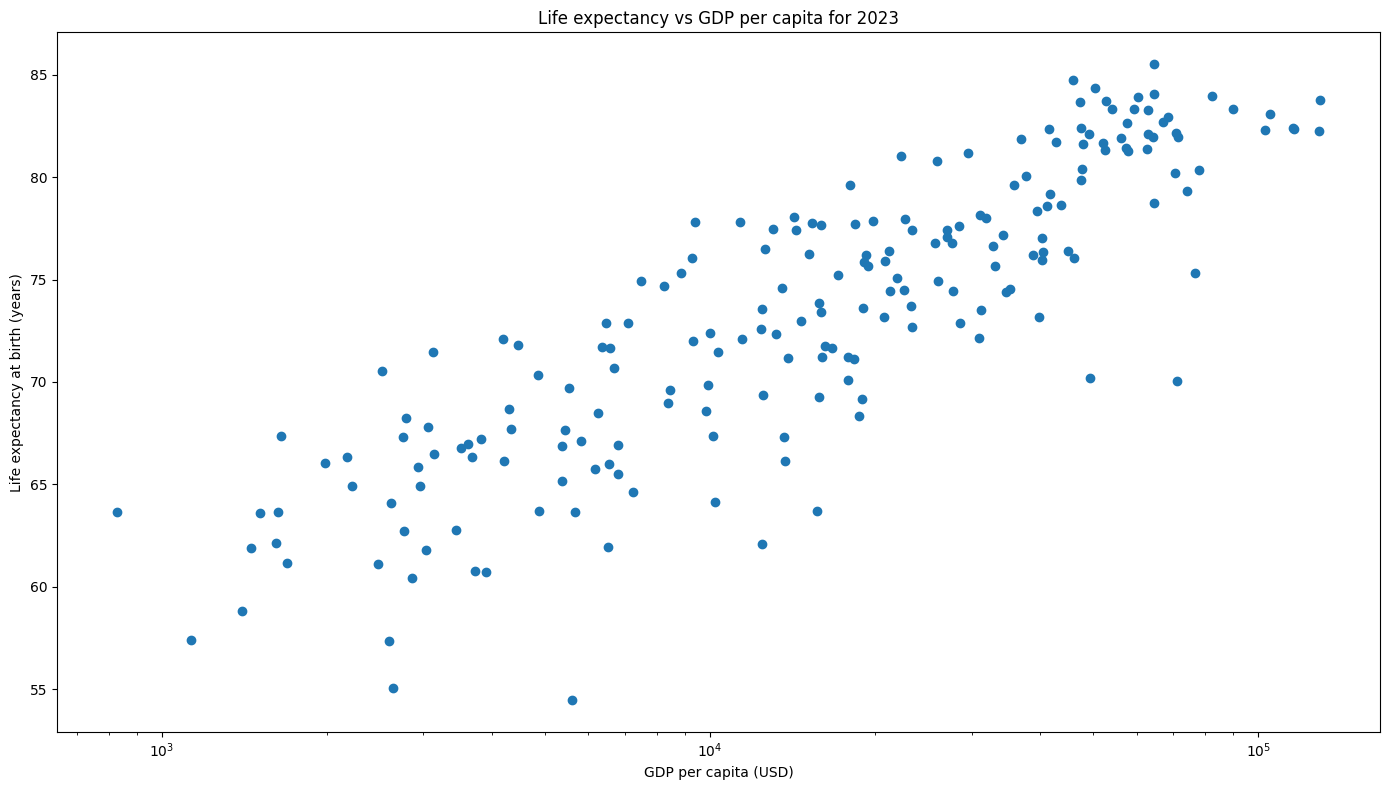

In [28]:
plt.figure(figsize=(14,8))
plt.scatter(merged_df['GDP_per_capita'], merged_df['Life_expectancy'])
plt.xscale('log')
plt.xlabel(f'GDP per capita (USD)')
plt.ylabel('Life expectancy at birth (years)')
plt.title('Life expectancy vs GDP per capita for 2023')

plt.tight_layout()
plt.show()

A strong correlation between the GDP per capita and the Life expectancy of a person can be seen. The more the GDP per capita is, the more is the average life expectancy of a person in the country.

Let's now compare this result to the earliest year visible in both datasets.

In [29]:
earliest_year = common_years[0]
earliest_year

1990

In [30]:
gdp_1990 = gdp_df[gdp_df['Year'] == earliest_year][['Entity', 'GDP_per_capita']]
life_expectancy_1990 = life_expectancy_df[life_expectancy_df['Year'] == earliest_year][['Entity', 'Life_expectancy']]

merged_df_1990 = pd.merge(gdp_1990, life_expectancy_1990, on='Entity', how='inner')

merged_df_1990 = merged_df_1990.dropna(subset=['GDP_per_capita', 'Life_expectancy'])

merged_df_1990 = merged_df_1990.dropna(subset=['GDP_per_capita', 'Life_expectancy']).reset_index(drop=True)

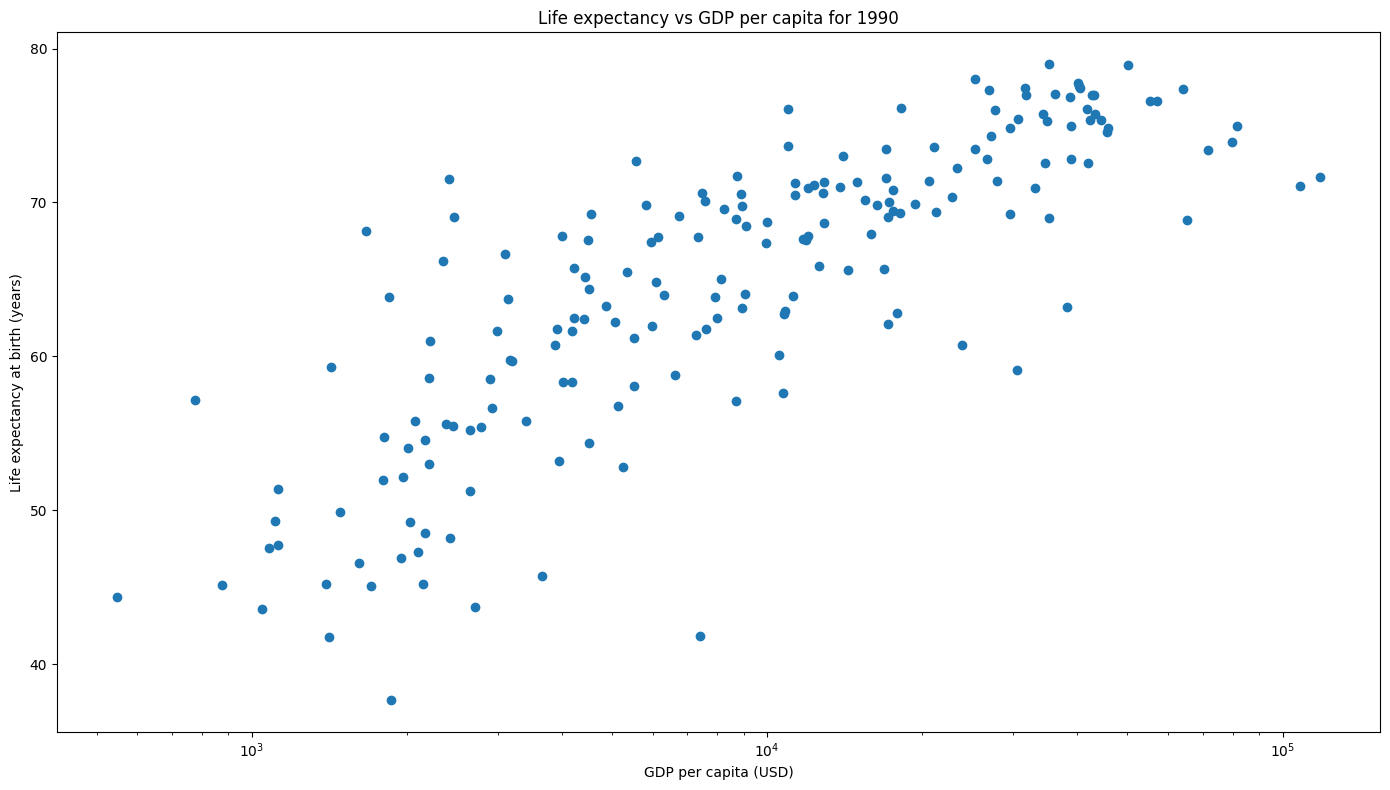

In [31]:
plt.figure(figsize=(14,8))
plt.scatter(merged_df_1990['GDP_per_capita'], merged_df_1990['Life_expectancy'])
plt.xscale('log')
plt.xlabel(f'GDP per capita (USD)')
plt.ylabel('Life expectancy at birth (years)')
plt.title('Life expectancy vs GDP per capita for 1990')

plt.tight_layout()
plt.show()

In conclusion, we can see that the correlation between the two features is also visible in 1990 although there are some more distractions in the data.

### Analyzing the results

b. Which countries have a life expectancy higher than one standard deviation
above the mean?

In [38]:
life_expectancy_mean = merged_df['Life_expectancy'].mean()
life_expectancy_std = merged_df['Life_expectancy'].std()
life_expectancy_requirements = life_expectancy_mean + life_expectancy_std

high_life_expectancy = merged_df[merged_df['Life_expectancy'] > life_expectancy_requirements].sort_values(
    'Life_expectancy', ascending=False
).reset_index(drop=True)

print(high_life_expectancy[['Entity','Life_expectancy','GDP_per_capita']])

                   Entity  Life_expectancy  GDP_per_capita
0               Hong Kong          85.5106       64428.730
1                   Japan          84.7123       45858.660
2             South Korea          84.3288       50414.207
3                 Andorra          84.0406       64631.297
4             Switzerland          83.9536       82302.050
5               Australia          83.9228       60461.156
6               Singapore          83.7362      129555.240
7                   Italy          83.7157       52725.746
8                   Spain          83.6703       47341.170
9                  France          83.3253       54017.875
10                 Norway          83.3078       90085.555
11                  Malta          83.2989       59293.297
12                 Sweden          83.2624       62845.484
13                  Macao          83.0749      104961.920
14   United Arab Emirates          82.9091       68577.540
15                Iceland          82.6911       67177.2

41 contries are with so high life expectancy as it is visible in the list above.

Let's see where these contries stand on the scatter plot we showed above.

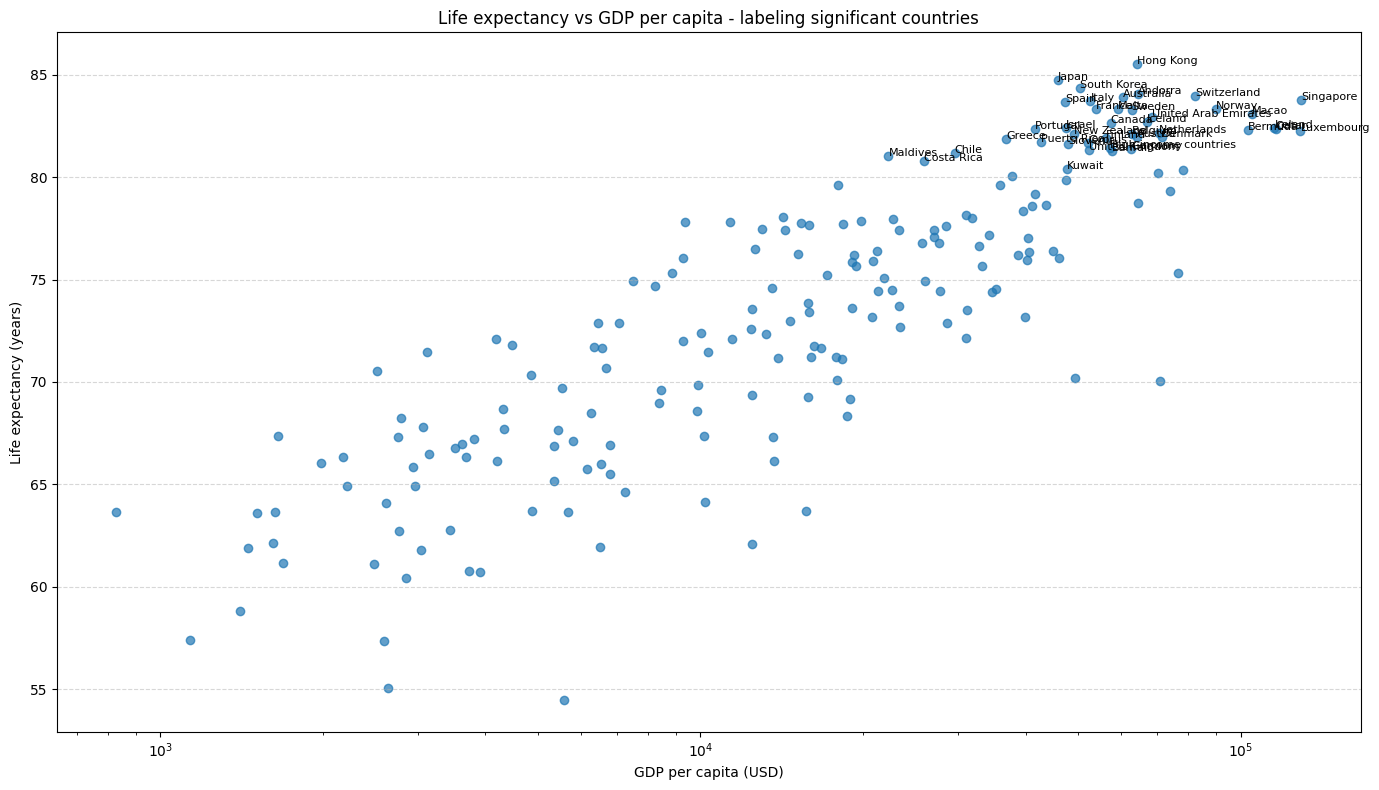

In [39]:
plt.figure(figsize=(14,8))
plt.scatter(merged_df['GDP_per_capita'], merged_df['Life_expectancy'], alpha=0.7)
plt.xscale('log')
plt.xlabel(f'GDP per capita (USD)')
plt.ylabel('Life expectancy (years)')
plt.title('Life expectancy vs GDP per capita - labeling significant countries')
plt.grid(axis='y', linestyle='--', alpha=0.5)

significant_countries = pd.concat([
    high_life_expectancy,
]).drop_duplicates('Entity')

for _, r in significant_countries.iterrows():
    plt.annotate(r['Entity'], (r['GDP_per_capita'], r['Life_expectancy']), fontsize=8)

plt.tight_layout()
plt.show()

The contries with life expectancy higher than one standard deviation
above the mean are mostly with very high GDP per capita (they are situated in the upper right corner of the scatter plot)

Let's zoom it in to see where

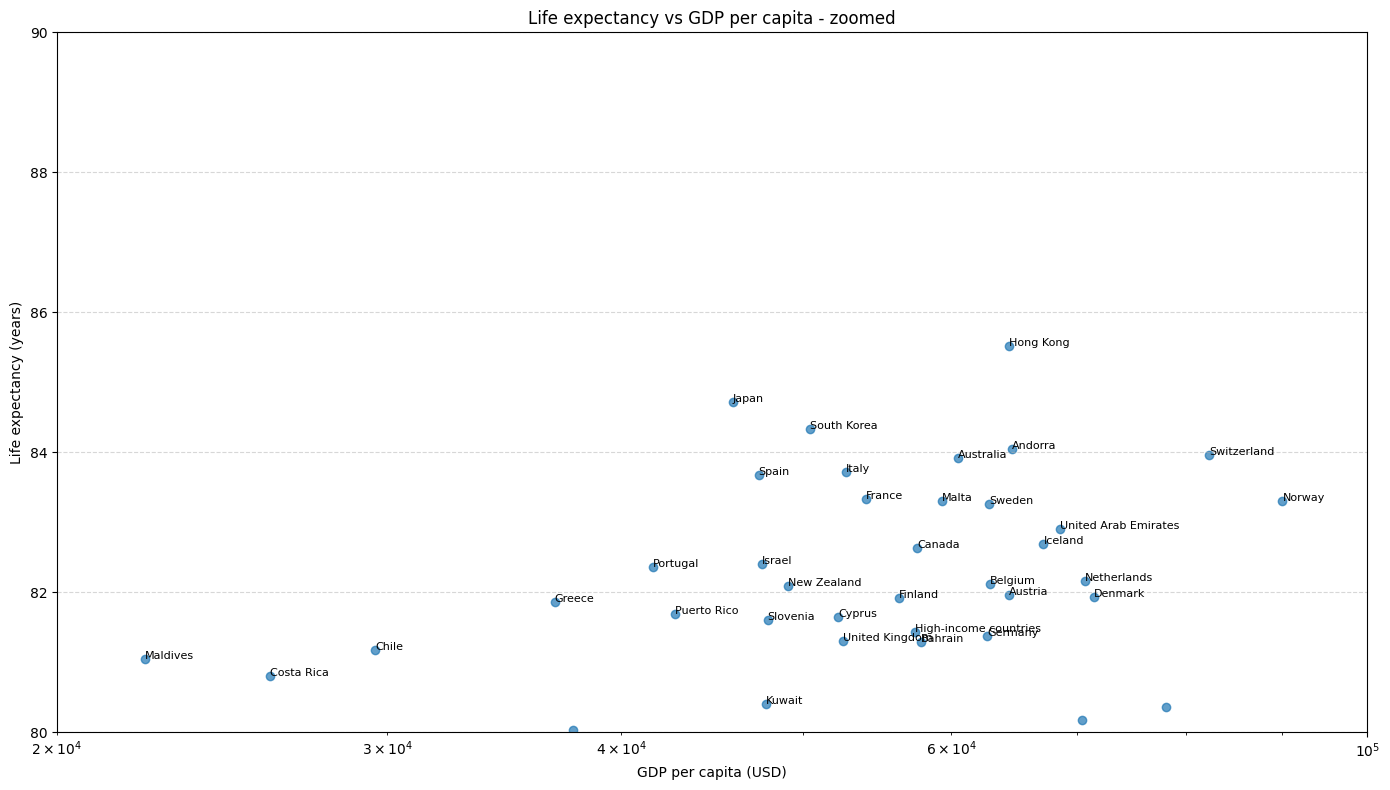

In [40]:
plt.figure(figsize=(14,8))
plt.scatter(merged_df['GDP_per_capita'], merged_df['Life_expectancy'], alpha=0.7)
plt.xscale('log')
plt.xlabel(f'GDP per capita (USD)')
plt.ylabel('Life expectancy (years)')
plt.title('Life expectancy vs GDP per capita - zoomed')
plt.grid(axis='y', linestyle='--', alpha=0.5)

significant_countries = pd.concat([
    high_life_expectancy,
]).drop_duplicates('Entity')

for _, r in significant_countries.iterrows():
    plt.annotate(r['Entity'], (r['GDP_per_capita'], r['Life_expectancy']), fontsize=8)

plt.xlim(2e4, 1e5)
plt.ylim(80, 90)

plt.tight_layout()
plt.show()


c. Which countries have high life expectancy but have low GDP? Motivate how
you have chosen to define “high” and “low”

We can define Low and High depending on the situation and the needs of the experiment. It can be defined just above and below the mean value. In the first experiment, we will check for the countries which have GDP per capita in the first quantile, meaning below 25%. For now, we will keep the definition of High life expectancy from the previous task.

In [42]:
gdp_quantile_25 = merged_df['GDP_per_capita'].quantile(0.25)
life_expectancy_requirements = life_expectancy_mean + life_expectancy_std
high_life_exp_and_low_gdp = merged_df[(merged_df['Life_expectancy'] > life_expectancy_requirements) & (merged_df['GDP_per_capita'] < gdp_quantile_25)].sort_values('GDP_per_capita')

high_life_exp_and_low_gdp[['Entity','Life_expectancy','GDP_per_capita']]

,Entity,Life_expectancy,GDP_per_capita


As we see, such countries doesn't exist.
Let's try with GDP below the mean value.

In [48]:
gdp_quantile_50 = merged_df['GDP_per_capita'].mean()
high_life_exp_and_low_gdp = merged_df[(merged_df['Life_expectancy'] > life_expectancy_requirements) & (merged_df['GDP_per_capita'] < gdp_quantile_50)].sort_values('GDP_per_capita')

high_life_exp_and_low_gdp[['Entity','Life_expectancy','GDP_per_capita']]

,Entity,Life_expectancy,GDP_per_capita
113,Maldives,81.0412,22286.980
42,Costa Rica,80.7995,25979.629


We can see that Maldives and Costa Rica are such countries, most probably because of the good conditions in the countries.

In conclusion, we will decrease the life expectancy threshold to the mean value.

In [50]:
gdp_quantile_50 = merged_df['GDP_per_capita'].mean()
high_life_exp_and_low_gdp = merged_df[(merged_df['Life_expectancy'] > life_expectancy_mean) & (merged_df['GDP_per_capita'] < gdp_quantile_50)].sort_values('Life_expectancy')

high_life_exp_and_low_gdp[['Entity','Life_expectancy','GDP_per_capita']]

,Entity,Life_expectancy,GDP_per_capita
190,Ukraine,73.4225,15916.9580
18,Belize,73.5656,12455.2960
174,Suriname,73.6310,19043.7050
52,Dominican Republic,73.7201,23282.4900
143,Paraguay,73.8443,15826.0880
11,Azerbaijan,74.4286,21310.7380
67,Georgia,74.4965,22590.5300
198,Vietnam,74.5883,13545.9350
14,Bangladesh,74.6723,8242.3980
118,Mauritius,74.9263,26060.7320


In this example much more countries exist, however, the requirements are just life expectancy above the mean value and GDP per capita below the mean value which involves countries right in the middle. This last result is not giving correct enough information on the subject.

d. Does every strong economy (normally indicated by GDP) have high life expectancy?

In [54]:
top_economy = merged_df['GDP_per_capita'].quantile(0.75)
strong_economy = merged_df[merged_df['GDP_per_capita'] >= top_economy].sort_values('GDP_per_capita', ascending=False)
strong_economy_low_life_expectancy = strong_economy[ strong_economy['Life_expectancy'] <= life_expectancy_mean ]

strong_economy_low_life_expectancy

,Entity,GDP_per_capita,Life_expectancy
71,Greenland,71037.54,70.0550
76,Guyana,49312.36,70.1802


Although only two countries complete the requirements, this is prooving that the high economy is not ensuring high life expectancy.

e. Related to question d, what would happen if you use GDP per capita as an
indicator of strong economy? Explain the results you obtained, and discuss
any insights you get from comparing the results of d and e

In [56]:
correlation = merged_df[['GDP_per_capita','Life_expectancy']].corr().iloc[0,1]
print(f"Correlation between GDP per capita and life expectancy: {correlation:.3f}")

Correlation between GDP per capita and life expectancy: 0.744


In conclusion, we can see that the correlation is almost 0.75 which is in the highest 25%, however it is not enough to conclude that high GDP per capita results in a strong economy.